# 응용동역학 실습 노트북 — SDOF 진동, Newmark 적분, 응답스펙트럼

초고층내진계약학과 · 응용동역학 (2026-2)

| 파트 | 주제 | 핵심 질문 |
| --- | --- | --- |
| 0 | 준비 | 공통 함수와 단위 규칙 |
| 1 | SDOF 자유진동 | 감쇠비는 응답에서 어떻게 보이나 |
| 2 | 조화하중 강제진동 | 공진에서 응답은 얼마나, 얼마나 빨리 커지나 |
| 3 | Newmark-β 적분 | dt는 얼마나 작아야 하나, 언제 발산하나 |
| 4 | 지진 지반운동 응답 | 지반가속도를 하중으로 바꾸는 법 |
| 5 | 응답스펙트럼 | 설계에 쓰는 한 장의 그래프는 어떻게 만들어지나 |

**사용법**

1. 위에서부터 순서대로 `Shift + Enter`로 실행합니다. 셀 순서를 건너뛰면 변수가 없다는 오류가 납니다.
2. `✏️ 실습` 셀은 값을 바꿔 보라고 만든 셀입니다. **바꾸기 전에 결과를 먼저 예측**하고 실행하세요.
3. 모든 계산 셀은 끝에 `[PASS]` / `[FAIL]` 판정을 찍습니다. `[FAIL]`이 나오면 그래프보다 그 줄을 먼저 보세요.

필요 패키지: `pip install numpy matplotlib` (Colab에는 이미 설치되어 있습니다)

> 이 수업의 3대 원칙 — ① 숫자는 코드가 계산한다 ② 단위는 변수 이름에 쓴다 ③ AI 답은 검증 전까지 가설이다

## 0. 준비 — 패키지와 공통 함수

그래프 축 라벨은 영문으로 둡니다. 한글 폰트가 없는 PC에서도 깨지지 않게 하기 위해서입니다.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

G_M_PER_S2 = 9.80665   # 표준중력가속도 [m/s^2]


def verdict(ok):
    return "[PASS]" if ok else "[FAIL]"


print("준비 완료. numpy", np.__version__)

준비 완료. numpy 2.5.3


In [2]:
def newmark_linear(m, c, k, p, dt, u0=0.0, v0=0.0, gamma=0.5, beta=0.25):
    """선형 SDOF Newmark-beta 적분 (Chopra, Dynamics of Structures, Table 5.4.2).

    m, c, k : 질량 [kg], 감쇠계수 [N*s/m], 강성 [N/m]
    p       : 하중 시간이력 배열 [N] (등간격 dt)
    gamma, beta : 0.5, 0.25  -> 평균가속도법 (무조건 안정)
                  0.5, 1/6   -> 선형가속도법 (dt/Tn <= 0.551 일 때만 안정)
    반환     : 변위 u [m], 속도 v [m/s], 가속도 a [m/s^2]
    """
    p = np.asarray(p, dtype=float)
    n = len(p)
    u = np.zeros(n)
    v = np.zeros(n)
    a = np.zeros(n)
    u[0], v[0] = u0, v0
    a[0] = (p[0] - c * v0 - k * u0) / m          # 초기 가속도는 운동방정식에서

    k_hat = k + gamma / (beta * dt) * c + m / (beta * dt**2)
    a1 = m / (beta * dt**2) + gamma / (beta * dt) * c
    a2 = m / (beta * dt) + (gamma / beta - 1.0) * c
    a3 = (1.0 / (2.0 * beta) - 1.0) * m + dt * (gamma / (2.0 * beta) - 1.0) * c

    for i in range(n - 1):
        p_hat = p[i + 1] + a1 * u[i] + a2 * v[i] + a3 * a[i]
        u[i + 1] = p_hat / k_hat
        v[i + 1] = (gamma / (beta * dt) * (u[i + 1] - u[i])
                    + (1.0 - gamma / beta) * v[i]
                    + dt * (1.0 - gamma / (2.0 * beta)) * a[i])
        a[i + 1] = ((u[i + 1] - u[i]) / (beta * dt**2)
                    - v[i] / (beta * dt)
                    - (1.0 / (2.0 * beta) - 1.0) * a[i])
    return u, v, a


def find_peaks_simple(x):
    """이웃 두 점보다 큰 양의 극댓값 인덱스 (scipy 없이)."""
    return np.where((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]) & (x[1:-1] > 0))[0] + 1


print("newmark_linear, find_peaks_simple 정의 완료")

newmark_linear, find_peaks_simple 정의 완료


---
## 1. SDOF 감쇠 자유진동

$$m\ddot{u} + c\dot{u} + ku = 0,\qquad u(0)=u_0,\ \dot{u}(0)=v_0$$

| 기호 | 정의 | 의미 |
| --- | --- | --- |
| $\omega_n=\sqrt{k/m}$ | 고유각진동수 | 감쇠가 없을 때 진동 속도 |
| $\zeta = c/c_{cr},\ c_{cr}=2\sqrt{km}$ | 감쇠비 | 5%는 `0.05` (5가 아님) |
| $\omega_D=\omega_n\sqrt{1-\zeta^2}$ | 감쇠고유각진동수 | 실제로 관측되는 진동 |

저감쇠($\zeta<1$) 해석해:

$$u(t)=e^{-\zeta\omega_n t}\left[u_0\cos\omega_D t+\frac{v_0+\zeta\omega_n u_0}{\omega_D}\sin\omega_D t\right]$$

입력값은 예제 1(`examples/01_sdof_free_vibration`)과 같습니다. 100 ton, 4,000 kN/m, 5%.

In [3]:
# ---- 입력: SI 기본단위 (kg, N, m, s) ----
m_kg = 1.0e5           # 100 ton
k_N_per_m = 4.0e6      # 4,000 kN/m
zeta = 0.05            # 5%
u0_m = 0.02            # 20 mm
v0_m_per_s = 0.0

# ---- 단위 방어선: 틀린 단위면 여기서 멈춘다 ----
assert 1e3 < m_kg < 1e8, "kg 단위인가? ton을 그대로 넣지 않았나"
assert 1e5 < k_N_per_m < 1e10, "N/m 단위인가? kN/m를 그대로 넣지 않았나"
assert 0.0 <= zeta < 1.0, "저감쇠 범위(0~1)가 아니다. 5%는 0.05"

wn = np.sqrt(k_N_per_m / m_kg)
Tn_s = 2 * np.pi / wn
wD = wn * np.sqrt(1 - zeta**2)
TD_s = 2 * np.pi / wD
c_Ns_per_m = 2 * zeta * np.sqrt(k_N_per_m * m_kg)

print(f"wn = {wn:.4f} rad/s,  Tn = {Tn_s:.4f} s")
print(f"TD = {TD_s:.4f} s  (Tn보다 {100*(TD_s/Tn_s-1):.3f}% 길다 -> 5% 감쇠에서는 사실상 같다)")
print(f"c  = {c_Ns_per_m:.4e} N*s/m")

wn = 6.3246 rad/s,  Tn = 0.9935 s
TD = 0.9947 s  (Tn보다 0.125% 길다 -> 5% 감쇠에서는 사실상 같다)
c  = 6.3246e+04 N*s/m


### 1-1. 해석해와 Newmark 수치해를 나란히 — 서로 검증

두 방법이 1% 이내로 겹치지 않으면 어느 한쪽이 틀린 것입니다.

[검증] Newmark vs 해석해 최대 상대오차 = 0.0606 %  [PASS]


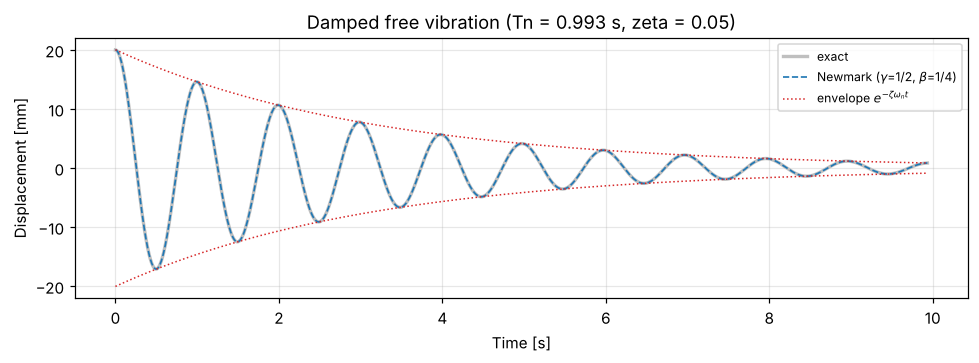

In [4]:
n_cycles, pts_per_cycle = 10, 200
dt_s = Tn_s / pts_per_cycle
t_s = np.arange(0.0, n_cycles * Tn_s, dt_s)

B = (v0_m_per_s + zeta * wn * u0_m) / wD
u_exact = np.exp(-zeta * wn * t_s) * (u0_m * np.cos(wD * t_s) + B * np.sin(wD * t_s))
u_num, _, _ = newmark_linear(m_kg, c_Ns_per_m, k_N_per_m, np.zeros_like(t_s), dt_s, u0_m, v0_m_per_s)

err = np.max(np.abs(u_num - u_exact)) / np.max(np.abs(u_exact))
print(f"[검증] Newmark vs 해석해 최대 상대오차 = {err*100:.4f} %  {verdict(err < 1e-2)}")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(t_s, u_exact * 1e3, lw=2.2, color="0.75", label="exact")
ax.plot(t_s, u_num * 1e3, "--", lw=1.1, color="C0", label=r"Newmark ($\gamma$=1/2, $\beta$=1/4)")
env = np.sqrt(u0_m**2 + B**2) * np.exp(-zeta * wn * t_s)
ax.plot(t_s, env * 1e3, ":", color="C3", lw=1, label=r"envelope $e^{-\zeta\omega_n t}$")
ax.plot(t_s, -env * 1e3, ":", color="C3", lw=1)
ax.set_xlabel("Time [s]"); ax.set_ylabel("Displacement [mm]")
ax.set_title(f"Damped free vibration (Tn = {Tn_s:.3f} s, zeta = {zeta:.2f})")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 1-2. 감쇠비를 바꾸면 — 임계감쇠까지

해석해는 $\zeta<1$에서만 위 식이 맞습니다. **Newmark는 감쇠비에 상관없이 그대로 돌아갑니다.**
수치적분이 실무에서 쓰이는 이유 중 하나입니다.

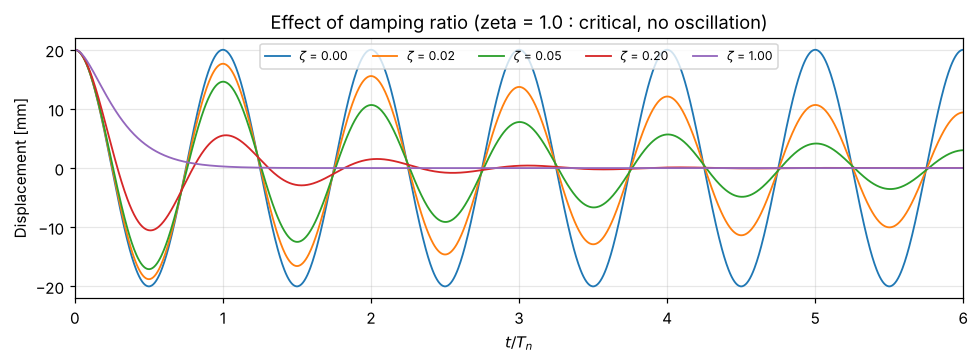

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.4))
for z in (0.0, 0.02, 0.05, 0.20, 1.00):
    c_z = 2 * z * np.sqrt(k_N_per_m * m_kg)
    u_z, _, _ = newmark_linear(m_kg, c_z, k_N_per_m, np.zeros_like(t_s), dt_s, u0_m, 0.0)
    ax.plot(t_s / Tn_s, u_z * 1e3, lw=1.2, label=rf"$\zeta$ = {z:.2f}")
ax.set_xlabel(r"$t / T_n$"); ax.set_ylabel("Displacement [mm]")
ax.set_title("Effect of damping ratio (zeta = 1.0 : critical, no oscillation)")
ax.set_xlim(0, 6); ax.legend(fontsize=8, ncol=5); plt.tight_layout(); plt.show()

### 1-3. 응답에서 감쇠비 역산 — 대수감쇠율

진동대·상시진동 계측에서 감쇠비를 구하는 방법입니다. $j$주기 떨어진 두 피크 $u_i,\ u_{i+j}$로

$$\delta = \frac{1}{j}\ln\frac{u_i}{u_{i+j}},\qquad \zeta = \frac{\delta}{\sqrt{4\pi^2+\delta^2}}$$

입력한 `zeta`가 그대로 복원되면 코드와 이론이 모두 맞다는 뜻입니다.

In [6]:
pk = find_peaks_simple(u_num)
j = 5
delta = np.log(u_num[pk[0]] / u_num[pk[j]]) / j
zeta_back = delta / np.sqrt(4 * np.pi**2 + delta**2)
rel = abs(zeta_back - zeta) / zeta
print(f"피크 {len(pk)}개 검출, {j}주기 간격 사용")
print(f"delta = {delta:.6f},  역산 zeta = {zeta_back:.6f} (입력 {zeta:.6f}),  오차 {rel*100:.4f} %  {verdict(rel < 1e-2)}")
print(f"간이식 zeta ~ delta/(2*pi) = {delta/(2*np.pi):.6f}  (감쇠가 작을 때만 쓸 만하다)")

피크 9개 검출, 5주기 간격 사용
delta = 0.314510,  역산 zeta = 0.049993 (입력 0.050000),  오차 0.0137 %  [PASS]
간이식 zeta ~ delta/(2*pi) = 0.050056  (감쇠가 작을 때만 쓸 만하다)


### ✏️ 실습 1

아래 셀의 값을 바꾸고, **실행 전에 먼저 예측**해 보세요.

1. `zeta_try = 0.10` → 5주기 뒤 진폭은 처음의 몇 %? (예측: $e^{-2\pi\zeta\cdot 5}$)
2. `u0_try = 0`, `v0_try = 0.1` (m/s) → 최대 변위는 대략 $v_0/\omega_n$ 근처인가?
3. 일부러 `k_try = 4000` (kN/m 그대로)을 넣어 보세요. 어디서 멈추나요?

최대 |u| = 20.000 mm,   v0/wn = 0.000 mm
이론 5주기 감소비 exp(-2*pi*zeta*5) = 4.32 %


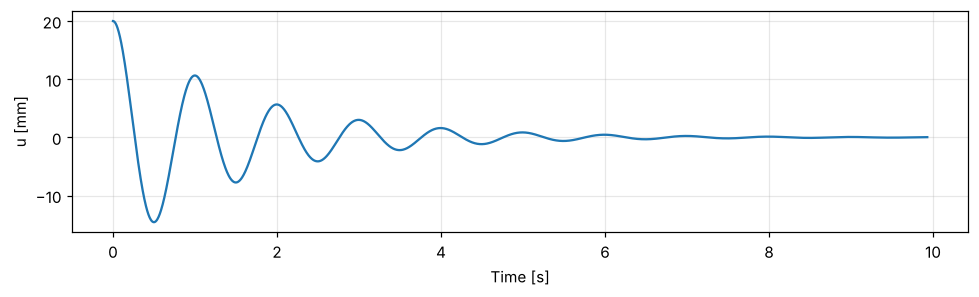

In [7]:
zeta_try, u0_try, v0_try, k_try = 0.10, 0.02, 0.0, 4.0e6     # ← 바꿔 보세요

assert 1e5 < k_try < 1e10, "N/m 단위인가? kN/m를 그대로 넣지 않았나"
c_try = 2 * zeta_try * np.sqrt(k_try * m_kg)
wn_try = np.sqrt(k_try / m_kg)
dt_try = (2 * np.pi / wn_try) / 200
t_try = np.arange(0, 10 * 2 * np.pi / wn_try, dt_try)
u_try, _, _ = newmark_linear(m_kg, c_try, k_try, np.zeros_like(t_try), dt_try, u0_try, v0_try)

print(f"최대 |u| = {np.max(np.abs(u_try))*1e3:.3f} mm,   v0/wn = {v0_try/wn_try*1e3:.3f} mm")
print(f"이론 5주기 감소비 exp(-2*pi*zeta*5) = {np.exp(-2*np.pi*zeta_try*5)*100:.2f} %")
plt.figure(figsize=(9, 2.8)); plt.plot(t_try, u_try * 1e3)
plt.xlabel("Time [s]"); plt.ylabel("u [mm]"); plt.tight_layout(); plt.show()

---
## 2. 조화하중 강제진동

$$m\ddot{u}+c\dot{u}+ku=p_0\sin\omega t$$

정상상태 해: $u_p(t)=u_{st}\,R_d\,\sin(\omega t-\phi)$, $u_{st}=p_0/k$, $r=\omega/\omega_n$

$$R_d=\frac{1}{\sqrt{(1-r^2)^2+(2\zeta r)^2}},\qquad \phi=\tan^{-1}\frac{2\zeta r}{1-r^2}$$

| 구간 | $R_d$ | 지배 요소 |
| --- | --- | --- |
| $r \ll 1$ | $\approx 1$ | 강성 (정적과 같다) |
| $r \approx 1$ | $\approx 1/(2\zeta)$ | **감쇠** |
| $r \gg 1$ | $\approx 1/r^2 \to 0$ | 질량 (면진의 원리) |

u_st = 12.50 mm
[검증] 피크: 수치 r=0.9970, Rd=10.0120 / 이론 r=0.9975, Rd=10.0125  [PASS]


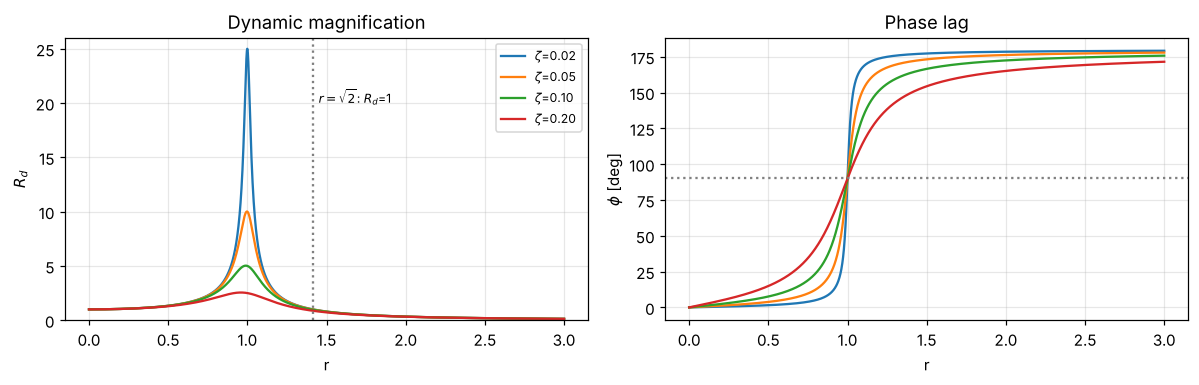

In [8]:
p0_N = 5.0e4                        # 50 kN
u_st_m = p0_N / k_N_per_m

def Rd(r, z):
    return 1.0 / np.sqrt((1 - r**2) ** 2 + (2 * z * r) ** 2)

def phase_deg(r, z):
    return np.degrees(np.arctan2(2 * z * r, 1 - r**2))

r_grid = np.linspace(0.0, 3.0, 3001)
i_pk = np.argmax(Rd(r_grid, zeta))
Rd_exact = 1 / (2 * zeta * np.sqrt(1 - zeta**2))
ok = abs(Rd(r_grid, zeta)[i_pk] - Rd_exact) / Rd_exact < 1e-3
print(f"u_st = {u_st_m*1e3:.2f} mm")
print(f"[검증] 피크: 수치 r={r_grid[i_pk]:.4f}, Rd={Rd(r_grid, zeta)[i_pk]:.4f} / "
      f"이론 r={np.sqrt(1-2*zeta**2):.4f}, Rd={Rd_exact:.4f}  {verdict(ok)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for z in (0.02, 0.05, 0.10, 0.20):
    axes[0].plot(r_grid, Rd(r_grid, z), label=rf"$\zeta$={z:.2f}")
    axes[1].plot(r_grid, phase_deg(r_grid, z), label=rf"$\zeta$={z:.2f}")
axes[0].set_ylim(0, 26); axes[0].set_xlabel("r"); axes[0].set_ylabel(r"$R_d$"); axes[0].legend(fontsize=8)
axes[0].axvline(np.sqrt(2), color="0.5", ls=":"); axes[0].text(1.45, 20, r"$r=\sqrt{2}$: $R_d$=1", fontsize=8)
axes[1].axhline(90, color="0.5", ls=":"); axes[1].set_xlabel("r"); axes[1].set_ylabel(r"$\phi$ [deg]")
axes[0].set_title("Dynamic magnification"); axes[1].set_title("Phase lag")
plt.tight_layout(); plt.show()

### 2-1. 공진은 한 번에 오지 않는다 — 응답의 성장

정지 상태에서 $r=1$로 가진하면 진폭은 대략 다음 포락선을 따라 자랍니다 (Chopra 3.1절).

$$u_{env}(t)\approx \frac{u_{st}}{2\zeta}\left(1-e^{-\zeta\omega_n t}\right)$$

정상진폭의 95%에 도달하는 데 $t_{95}=\ln 20/(\zeta\omega_n)$이 걸립니다. 5% 감쇠면 약 **9.5주기**입니다.
지진동은 이렇게 오래 같은 진동수로 흔들지 않기 때문에, 지진 응답은 보통 $1/(2\zeta)$배까지 가지 않습니다.

정상진폭 이론 = 125.00 mm (= u_st x 10.00),  수치(25~30주기) = 124.98 mm
[검증] 정상진폭 오차 0.018 %  [PASS]
95% 도달까지 9.5 주기


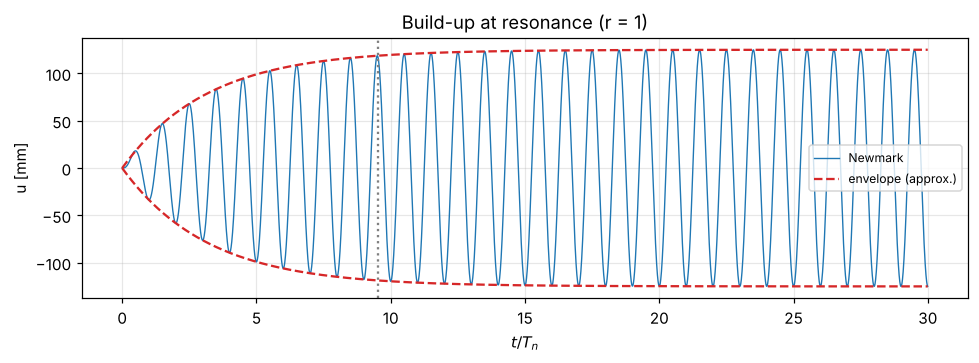

In [9]:
r_res = 1.0
w = r_res * wn
dt_f = Tn_s / 200
t_f = np.arange(0, 30 * Tn_s, dt_f)
u_f, _, _ = newmark_linear(m_kg, c_Ns_per_m, k_N_per_m, p0_N * np.sin(w * t_f), dt_f)

u_ss = u_st_m * Rd(r_res, zeta)
env = u_st_m / (2 * zeta) * (1 - np.exp(-zeta * wn * t_f))
t95_cycles = np.log(20) / (zeta * wn) / Tn_s

tail = t_f > 25 * Tn_s
amp_tail = np.max(np.abs(u_f[tail]))
err_ss = abs(amp_tail - u_ss) / u_ss
print(f"정상진폭 이론 = {u_ss*1e3:.2f} mm (= u_st x {Rd(r_res, zeta):.2f}),  수치(25~30주기) = {amp_tail*1e3:.2f} mm")
print(f"[검증] 정상진폭 오차 {err_ss*100:.3f} %  {verdict(err_ss < 1e-2)}")
print(f"95% 도달까지 {t95_cycles:.1f} 주기")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(t_f / Tn_s, u_f * 1e3, lw=0.9, label="Newmark")
ax.plot(t_f / Tn_s, env * 1e3, "--", color="C3", label="envelope (approx.)")
ax.plot(t_f / Tn_s, -env * 1e3, "--", color="C3")
ax.axvline(t95_cycles, color="0.5", ls=":")
ax.set_xlabel(r"$t/T_n$"); ax.set_ylabel("u [mm]"); ax.set_title("Build-up at resonance (r = 1)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### ✏️ 실습 2

1. `r_try`를 0.5, 1.0, 2.0으로 바꿔 보세요. 앞부분(과도응답)과 뒷부분(정상응답)의 모양이 어떻게 다른가요?
2. `zeta_f = 0.10`으로 올리면 정상진폭과 95% 도달 시간이 각각 몇 배가 되나요? (예측 먼저)
3. 점성댐퍼로 감쇠비를 2% → 10%로 올린 건물: 공진 응답은 몇 분의 1?

Rd = 0.333,  phi = 176.2 deg


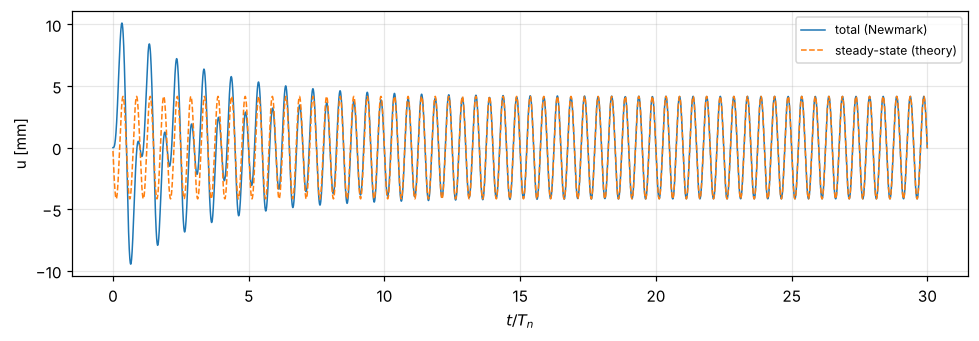

In [10]:
r_try, zeta_f = 2.0, 0.05                                    # ← 바꿔 보세요

c_f = 2 * zeta_f * np.sqrt(k_N_per_m * m_kg)
u_t, _, _ = newmark_linear(m_kg, c_f, k_N_per_m, p0_N * np.sin(r_try * wn * t_f), dt_f)
u_ss_t = u_st_m * Rd(r_try, zeta_f) * np.sin(r_try * wn * t_f - np.radians(phase_deg(r_try, zeta_f)))

print(f"Rd = {Rd(r_try, zeta_f):.3f},  phi = {phase_deg(r_try, zeta_f):.1f} deg")
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_f / Tn_s, u_t * 1e3, lw=1, label="total (Newmark)")
ax.plot(t_f / Tn_s, u_ss_t * 1e3, "--", lw=1, label="steady-state (theory)")
ax.set_xlabel(r"$t/T_n$"); ax.set_ylabel("u [mm]"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 3. Newmark-β 적분 — dt를 얼마나 잘게?

| 방법 | $\gamma$ | $\beta$ | 안정 조건 | 특징 |
| --- | --- | --- | --- | --- |
| 평균가속도법 | 1/2 | 1/4 | 무조건 안정 | 주기가 늘어남 (period elongation), 진폭 감소 없음 |
| 선형가속도법 | 1/2 | 1/6 | $\Delta t/T_n \le 0.551$ | 같은 dt에서 더 정확, 넘으면 **발산** |

"무조건 안정"은 "정확하다"가 아닙니다. 안정은 발산하지 않는다는 뜻뿐입니다.

### 3-1. 안정성 — 감쇠 0인 자유진동을 $\Delta t/T_n$를 바꿔 가며

감쇠가 0이면 진폭은 영원히 $u_0$여야 합니다. 진폭이 커지면 수치적으로 불안정한 것입니다.

 dt/Tn | method         |  max|u|/u0
  0.05 | average (1/4)  |          1
  0.05 | linear (1/6)   |          1
  0.20 | average (1/4)  |          1
  0.20 | linear (1/6)   |          1
  0.55 | average (1/4)  |          1
  0.55 | linear (1/6)   |          1
  0.60 | average (1/4)  |          1
  0.60 | linear (1/6)   |   2.21e+06


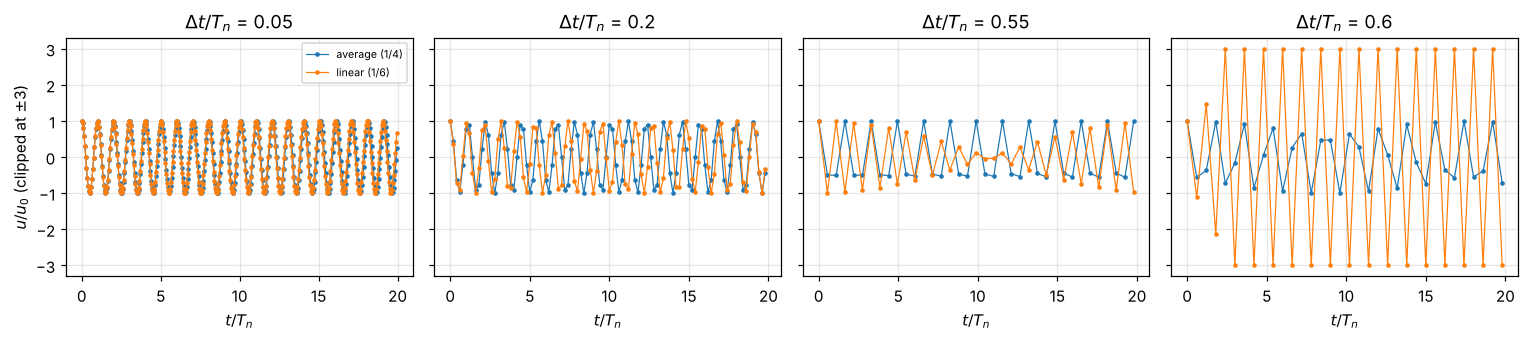

선형가속도법 이론 임계 dt/Tn = 0.5513  (0.55 안정, 0.60 발산이면 [PASS])


In [11]:
ratios = [0.05, 0.20, 0.55, 0.60]
methods = {"average (1/4)": 0.25, "linear (1/6)": 1 / 6}

fig, axes = plt.subplots(1, len(ratios), figsize=(14, 3.2), sharey=True)
print(f"{'dt/Tn':>6} | {'method':<14} | {'max|u|/u0':>10}")
for ax, rr in zip(axes, ratios):
    dt_r = rr * Tn_s
    t_r = np.arange(0, 20 * Tn_s, dt_r)
    for name, b in methods.items():
        u_r, _, _ = newmark_linear(m_kg, 0.0, k_N_per_m, np.zeros_like(t_r), dt_r, u0_m, 0.0, beta=b)
        growth = np.max(np.abs(u_r)) / u0_m
        print(f"{rr:6.2f} | {name:<14} | {growth:10.3g}")
        ax.plot(t_r / Tn_s, np.clip(u_r / u0_m, -3, 3), "o-", ms=2, lw=0.8, label=name)
    ax.set_title(rf"$\Delta t/T_n$ = {rr}"); ax.set_xlabel(r"$t/T_n$")
axes[0].set_ylabel(r"$u/u_0$ (clipped at $\pm$3)"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

b = 1 / 6
crit = 1 / (np.pi * np.sqrt(2)) / np.sqrt(0.5 - 2 * b)    # 선형가속도법 임계 dt/Tn
print(f"선형가속도법 이론 임계 dt/Tn = {crit:.4f}  (0.55 안정, 0.60 발산이면 {verdict(0.55 < crit < 0.60)})")

### 3-2. 정확도 — 주기 늘어남(period elongation)

평균가속도법이 계산하는 겉보기 주기 $\bar T$는 다음 식을 따릅니다 (사다리꼴 공식의 성질).

$$\frac{\bar T}{T_n}=\frac{\pi\Delta t/T_n}{\tan^{-1}(\pi\Delta t/T_n)}$$

수치해의 영점 교차에서 주기를 직접 재서 이 식과 비교합니다.

In [12]:
def measured_period(u, dt):
    # 하강 영점 교차 시각을 선형보간으로 구해 평균 간격을 주기로 본다
    idx = np.where((u[:-1] > 0) & (u[1:] <= 0))[0]
    tc = (idx + u[idx] / (u[idx] - u[idx + 1])) * dt
    return np.mean(np.diff(tc))

rows = []
for rr in (0.01, 0.02, 0.05, 0.10, 0.20, 0.30):
    dt_r = rr * Tn_s
    t_r = np.arange(0, 40 * Tn_s, dt_r)
    u_r, _, _ = newmark_linear(m_kg, 0.0, k_N_per_m, np.zeros_like(t_r), dt_r, u0_m, 0.0)
    Tbar_num = measured_period(u_r, dt_r) / Tn_s
    x = np.pi * rr
    Tbar_th = x / np.arctan(x)
    rows.append((rr, Tbar_num, Tbar_th))

print(f"{'dt/Tn':>6} | {'Tbar/Tn 수치':>12} | {'Tbar/Tn 이론':>12} | {'주기오차':>8}")
ok = True
for rr, a_, b_ in rows:
    print(f"{rr:6.2f} | {a_:12.5f} | {b_:12.5f} | {100*(a_-1):7.3f}%")
    ok &= abs(a_ - b_) < 2e-3
print(f"[검증] 수치 측정 주기 = 이론식  {verdict(ok)}")
print("=> dt <= Tn/10 이면 주기오차 약 3%, Tn/20 이면 약 0.8%")

 dt/Tn |   Tbar/Tn 수치 |   Tbar/Tn 이론 |     주기오차
  0.01 |      1.00033 |      1.00033 |   0.033%
  0.02 |      1.00131 |      1.00131 |   0.131%
  0.05 |      1.00817 |      1.00817 |   0.817%
  0.10 |      1.03207 |      1.03207 |   3.207%
  0.20 |      1.12003 |      1.12003 |  12.003%
  0.30 |      1.24651 |      1.24700 |  24.651%
[검증] 수치 측정 주기 = 이론식  [PASS]
=> dt <= Tn/10 이면 주기오차 약 3%, Tn/20 이면 약 0.8%


> **실무 연결.** 지진파는 보통 $\Delta t=0.01\sim0.02$ s로 주어집니다.
> $T_n=0.1$ s인 강체에 가까운 모드(또는 고차모드)에 $\Delta t=0.02$ s를 쓰면 $\Delta t/T_n=0.2$, 주기오차 약 13%입니다.
> 그래서 응답스펙트럼을 만들 때 짧은 주기에서는 **하중을 보간해서 dt를 잘게 쪼갭니다** (5장).

### ✏️ 실습 3

1. `beta_try = 1/6`, `ratio_try = 0.551` 과 `0.552`를 비교해 보세요. 200주기쯤 돌려야 차이가 보입니다.
2. 평균가속도법으로 주기오차를 1% 이하로 하려면 $\Delta t/T_n$는 얼마 이하? 위 이론식으로 직접 풀어 보세요.

In [13]:
beta_try, ratio_try, n_cyc_try = 1 / 6, 0.552, 200           # ← 바꿔 보세요

dt_r = ratio_try * Tn_s
t_r = np.arange(0, n_cyc_try * Tn_s, dt_r)
u_r, _, _ = newmark_linear(m_kg, 0.0, k_N_per_m, np.zeros_like(t_r), dt_r, u0_m, 0.0, beta=beta_try)
print(f"max|u|/u0 = {np.max(np.abs(u_r))/u0_m:.4g}   (1이면 안정, 계속 커지면 발산)")

max|u|/u0 = 4.47e+08   (1이면 안정, 계속 커지면 발산)


---
## 4. 지진 지반운동에 대한 SDOF 응답

지반이 $u_g(t)$로 움직이면, 상대변위 $u$에 대한 운동방정식은

$$m\ddot u + c\dot u + ku = -m\,\ddot u_g(t) \equiv p_{\text{eff}}(t)$$

**지진은 "질량에 비례하는 유효하중"**으로 바뀝니다. 그래서 질량 $m$과 무관하게 $T_n,\ \zeta$만으로 응답이 정해지고,
이것이 응답스펙트럼이 $T_n$ 하나의 축으로 그려지는 이유입니다.

사용 기록: **El Centro 1940, EW 성분** (`data/ElCentro_EW.txt`, 시간[s]–가속도[g] 두 열, GroundMotionScaling 예제와 같은 파일).

dt = 0.02 s,  N = 2501,  길이 = 50.0 s
PGA = 0.178 g,  PGV = 28.3 cm/s,  PGD = 119.6 cm (기선보정 전, 참고값)


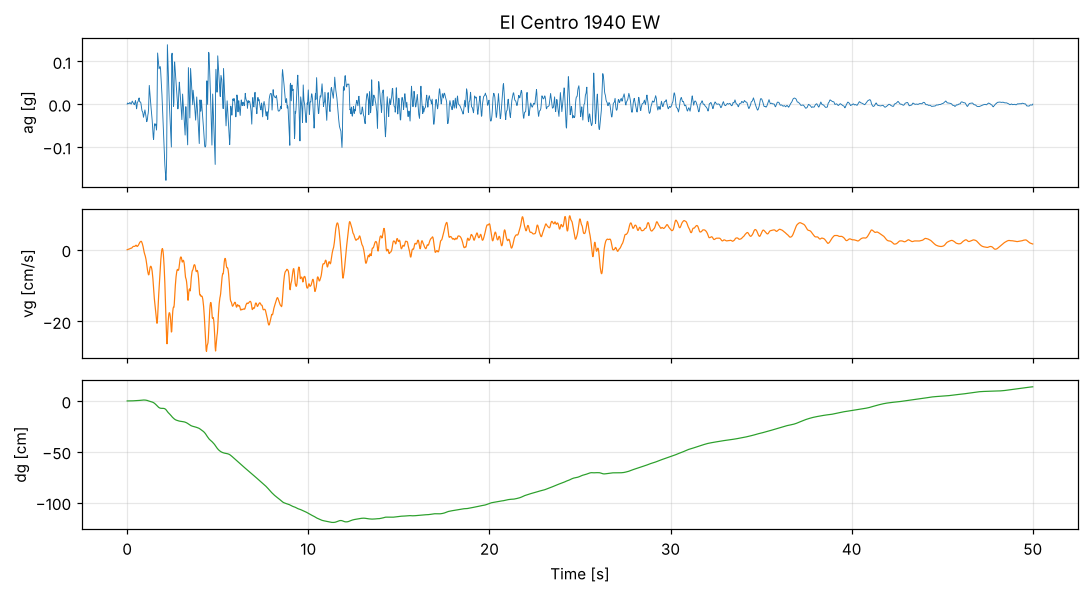

In [14]:
gm_path = Path("data/ElCentro_EW.txt")
if not gm_path.exists():
    # Colab 등에서 파일이 없으면 수업 저장소에서 받는다
    import urllib.request
    gm_path.parent.mkdir(exist_ok=True)
    url = ("https://raw.githubusercontent.com/titoliviomilazzo/StructuralDynamics2_2026/"
           "main/examples/03_inclass_notebook/data/ElCentro_EW.txt")
    urllib.request.urlretrieve(url, gm_path)

raw = np.loadtxt(gm_path, skiprows=1)
_, keep = np.unique(raw[:, 0], return_index=True)     # 시간 중복(t=0, 끝부분) 제거
raw = raw[np.sort(keep)]
# 시간열에 0.019999 / 0.020001 같은 반올림 잡음이 있다 -> 0.02 s 등간격으로 재샘플링
dt_g = 0.02
t_g = np.arange(0.0, raw[-1, 0] + 1e-9, dt_g)
ag_g = np.interp(t_g, raw[:, 0], raw[:, 1])            # 단위: g
assert np.max(np.abs(np.diff(raw[:, 0]) - dt_g)) < 1e-3, "원본 dt가 0.02 s가 아니다. dt_g를 확인하라"
assert np.max(np.abs(ag_g)) < 3.0, "g 단위가 맞나? (m/s^2 또는 gal이면 값이 훨씬 크다)"

ag_mps2 = ag_g * G_M_PER_S2
# 사다리꼴 적분으로 속도·변위 (기선보정 없음 -> PGD는 참고값)
vg = np.concatenate([[0], np.cumsum(0.5 * (ag_mps2[1:] + ag_mps2[:-1]) * dt_g)])
dg = np.concatenate([[0], np.cumsum(0.5 * (vg[1:] + vg[:-1]) * dt_g)])
PGA_g, PGV, PGD = np.max(np.abs(ag_g)), np.max(np.abs(vg)), np.max(np.abs(dg))
print(f"dt = {dt_g} s,  N = {len(t_g)},  길이 = {t_g[-1]:.1f} s")
print(f"PGA = {PGA_g:.3f} g,  PGV = {PGV*100:.1f} cm/s,  PGD = {PGD*100:.1f} cm (기선보정 전, 참고값)")

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(t_g, ag_g, lw=0.6); axes[0].set_ylabel("ag [g]")
axes[1].plot(t_g, vg * 100, lw=0.8, color="C1"); axes[1].set_ylabel("vg [cm/s]")
axes[2].plot(t_g, dg * 100, lw=0.8, color="C2"); axes[2].set_ylabel("dg [cm]")
axes[2].set_xlabel("Time [s]"); axes[0].set_title("El Centro 1940 EW")
plt.tight_layout(); plt.show()

> ⚠️ **확인 필요.** 이 파일의 PGA는 약 0.18 g입니다. 문헌에서 흔히 인용하는 El Centro 1940 EW(270°) PGA는 약 0.21 g이라
> 처리 방식(필터·기선보정·스케일)이 다른 버전일 수 있습니다. 수업 계산에는 지장이 없지만 문헌값과 비교할 때는 출처를 확인하세요.
>
> 적분 변위가 끝으로 갈수록 한쪽으로 흘러가는 것은 기선(baseline) 오차 때문입니다. 실무 기록은 기선보정·필터링을 거친 뒤 씁니다.

### 4-1. $T_n=1.0$ s, $\zeta=5\%$ 건물의 응답

$m=1$로 두고 풀어도 결과는 같습니다 (질량이 양변에서 약분됨). 이렇게 하면 $p_{\text{eff}}=-\ddot u_g$.
의사가속도 $A(t)=\omega_n^2u(t)$는 **밑면전단력 / 질량**, 즉 $V_b=mA$ 입니다.

Tn = 1.0 s, zeta = 0.05, dt/Tn = 0.020
최대 상대변위 D = 6.45 cm  (t = 4.42 s)
최대 의사가속도 A = 0.260 g  -> Vb/W = 0.260


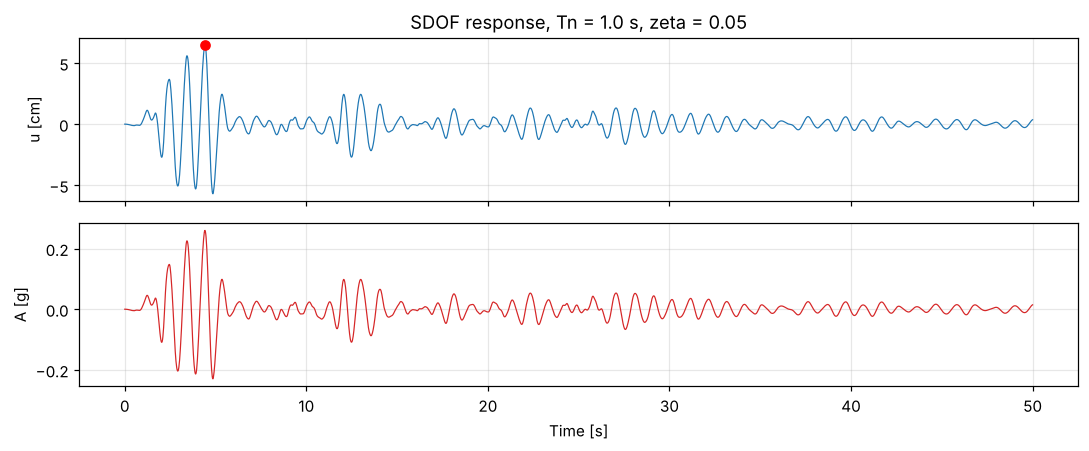

In [15]:
def sdof_ground(ag_mps2, dt, Tn, z, nsub=1):
    # 지반가속도에 대한 SDOF 응답 (m = 1). nsub > 1 이면 하중을 선형보간해 dt를 쪼갠다
    if nsub > 1:
        t_old = np.arange(len(ag_mps2)) * dt
        t_new = np.arange(0, t_old[-1] + 1e-12, dt / nsub)
        ag_mps2 = np.interp(t_new, t_old, ag_mps2)
        dt = dt / nsub
    w = 2 * np.pi / Tn
    u, v, a = newmark_linear(1.0, 2 * z * w, w**2, -ag_mps2, dt)
    return u, v, a, dt

Tn_eq, z_eq = 1.0, 0.05
u_eq, _, _, dt_eq = sdof_ground(ag_mps2, dt_g, Tn_eq, z_eq, nsub=1)
t_eq = np.arange(len(u_eq)) * dt_eq
A_eq = (2 * np.pi / Tn_eq) ** 2 * u_eq

i_max = np.argmax(np.abs(u_eq))
print(f"Tn = {Tn_eq} s, zeta = {z_eq}, dt/Tn = {dt_eq/Tn_eq:.3f}")
print(f"최대 상대변위 D = {abs(u_eq[i_max])*100:.2f} cm  (t = {t_eq[i_max]:.2f} s)")
print(f"최대 의사가속도 A = {np.max(np.abs(A_eq))/G_M_PER_S2:.3f} g  -> Vb/W = {np.max(np.abs(A_eq))/G_M_PER_S2:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 4.2), sharex=True)
axes[0].plot(t_eq, u_eq * 100, lw=0.8); axes[0].plot(t_eq[i_max], u_eq[i_max] * 100, "ro")
axes[0].set_ylabel("u [cm]"); axes[0].set_title(f"SDOF response, Tn = {Tn_eq} s, zeta = {z_eq}")
axes[1].plot(t_eq, A_eq / G_M_PER_S2, lw=0.8, color="C3"); axes[1].set_ylabel("A [g]")
axes[1].set_xlabel("Time [s]"); plt.tight_layout(); plt.show()

---
## 5. 응답스펙트럼

응답스펙트럼 = **여러 $T_n$의 SDOF에 같은 지진을 넣고, 각각의 최대응답만 모아 그린 그래프**.

$$D(T_n,\zeta)=\max_t|u(t)|,\qquad V=\omega_n D,\qquad A=\omega_n^2 D$$

$V$, $A$는 각각 의사속도(PSV), 의사가속도(PSA)입니다. 설계 스펙트럼 $S_a$는 $A$에 해당합니다.

**검증 방법:** 서로 독립인 두 방법으로 계산해서 겹치는지 봅니다.

1. Newmark 평균가속도법 + 짧은 주기에서 dt 분할 ($\Delta t \le T_n/20$)
2. 구간선형 정확해 (Chopra 5.2절, piecewise exact) — 하중이 구간 안에서 선형이면 dt와 무관하게 정확.
   단, **최댓값은 계산한 시점에서만 보이므로** 짧은 주기에서는 이것도 dt를 쪼개야 피크를 놓치지 않습니다.

In [16]:
def sdof_piecewise_exact(ag_mps2, dt, Tn, z, pts_per_T=20):
    # Chopra Table 5.2.1 의 계수로 계산하는 구간선형 정확해 (m = 1). 최대 |u| 반환
    # 해는 정확하지만 최댓값은 계산 시점에서만 본다 -> 짧은 주기에선 피크를 놓치지 않게 dt를 쪼갠다
    nsub = max(1, int(np.ceil(dt / (Tn / pts_per_T))))
    if nsub > 1:
        t_old = np.arange(len(ag_mps2)) * dt
        ag_mps2 = np.interp(np.arange(0, t_old[-1] + 1e-12, dt / nsub), t_old, ag_mps2)
        dt = dt / nsub
    w = 2 * np.pi / Tn
    k = w**2
    wd = w * np.sqrt(1 - z**2)
    sq = np.sqrt(1 - z**2)
    e, s, c = np.exp(-z * w * dt), np.sin(wd * dt), np.cos(wd * dt)
    A = e * (z / sq * s + c)
    B = e * s / wd
    C = (2 * z / (w * dt) + e * (((1 - 2 * z**2) / (wd * dt) - z / sq) * s - (1 + 2 * z / (w * dt)) * c)) / k
    D = (1 - 2 * z / (w * dt) + e * ((2 * z**2 - 1) / (wd * dt) * s + 2 * z / (w * dt) * c)) / k
    Ap = -e * w / sq * s
    Bp = e * (c - z / sq * s)
    Cp = (-1 / dt + e * ((w / sq + z / (dt * sq)) * s + c / dt)) / k
    Dp = (1 - e * (z / sq * s + c)) / (k * dt)
    p = (-ag_mps2).tolist()
    u = v = umax = 0.0
    for i in range(len(p) - 1):
        u, v = A * u + B * v + C * p[i] + D * p[i + 1], Ap * u + Bp * v + Cp * p[i] + Dp * p[i + 1]
        umax = max(umax, abs(u))
    return umax


def spectrum_newmark(ag_mps2, dt, periods, z, pts_per_T=20):
    D = np.zeros(len(periods))
    for j, T in enumerate(periods):
        nsub = max(1, int(np.ceil(dt / (T / pts_per_T))))
        u, _, _, _ = sdof_ground(ag_mps2, dt, T, z, nsub)
        D[j] = np.max(np.abs(u))
    return D


periods = np.logspace(np.log10(0.05), np.log10(10.0), 60)
D_ex = np.array([sdof_piecewise_exact(ag_mps2, dt_g, T, 0.05) for T in periods])
for ppt in (20, 40):
    D_nm = spectrum_newmark(ag_mps2, dt_g, periods, 0.05, pts_per_T=ppt)
    rel = np.abs(D_nm - D_ex) / D_ex
    print(f"Newmark dt <= Tn/{ppt}: 정확해 대비 최대 상대차 = {rel.max()*100:.2f} % (T = {periods[rel.argmax()]:.2f} s)")
print(f"[검증] Tn/40 분할 Newmark = 정확해 (3% 이내)  {verdict(rel.max() < 0.03)}")
print("=> 주기오차 0.8%(Tn/20)도 스펙트럼의 뾰족한 봉우리에서는 최댓값을 수 % 바꾼다")

Newmark dt <= Tn/20: 정확해 대비 최대 상대차 = 5.06 % (T = 0.43 s)


Newmark dt <= Tn/40: 정확해 대비 최대 상대차 = 1.43 % (T = 0.16 s)
[검증] Tn/40 분할 Newmark = 정확해 (3% 이내)  [PASS]
=> 주기오차 0.8%(Tn/20)도 스펙트럼의 뾰족한 봉우리에서는 최댓값을 수 % 바꾼다


### 5-1. dt를 쪼개지 않으면?

같은 Newmark인데 `pts_per_T`를 1(분할 없음)로 두면 짧은 주기에서 무슨 일이 생기는지 봅니다.

T = 0.050 s (dt/T = 0.40):  분할 없음 오차   27.1 %
T = 0.103 s (dt/T = 0.20):  분할 없음 오차    3.5 %
T = 0.192 s (dt/T = 0.10):  분할 없음 오차    0.8 %
T = 0.516 s (dt/T = 0.04):  분할 없음 오차    0.3 %


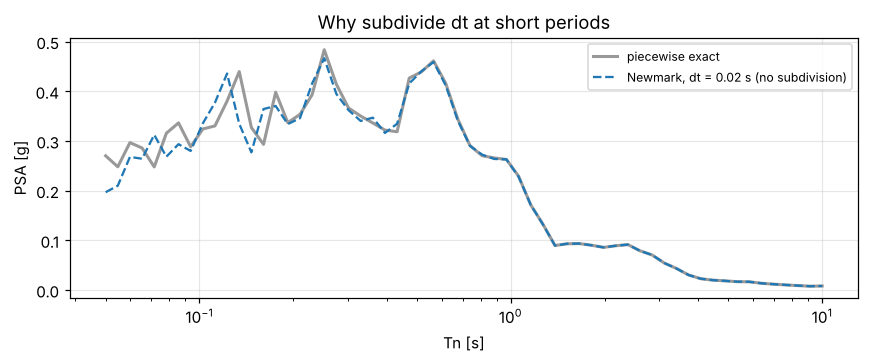

In [17]:
D_raw = np.array([np.max(np.abs(sdof_ground(ag_mps2, dt_g, T, 0.05, 1)[0])) for T in periods])
A_ex = (2 * np.pi / periods) ** 2 * D_ex / G_M_PER_S2
A_raw = (2 * np.pi / periods) ** 2 * D_raw / G_M_PER_S2

err_raw = np.abs(A_raw - A_ex) / A_ex
for T_chk in (0.05, 0.1, 0.2, 0.5):
    j = np.argmin(np.abs(periods - T_chk))
    print(f"T = {periods[j]:.3f} s (dt/T = {dt_g/periods[j]:.2f}):  분할 없음 오차 {err_raw[j]*100:6.1f} %")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.semilogx(periods, A_ex, lw=2, color="0.6", label="piecewise exact")
ax.semilogx(periods, A_raw, "--", label="Newmark, dt = 0.02 s (no subdivision)")
ax.set_xlabel("Tn [s]"); ax.set_ylabel("PSA [g]"); ax.legend(fontsize=8)
ax.set_title("Why subdivide dt at short periods"); plt.tight_layout(); plt.show()

### 5-2. 감쇠비별 스펙트럼 — D, V, A

세 가지 극한 검증:

- $T_n \to 0$ (아주 강한 구조): 건물이 지반과 같이 움직인다 → $A \to$ **PGA**
- $T_n \to \infty$ (아주 유연한 구조): 질량이 제자리에 있다 → $D \to$ **PGD**. 단 기선보정된 기록에서만 성립합니다.
  이 기록의 적분 PGD(약 120 cm)는 기선 오차라서 비교하지 않습니다
- 감쇠비가 클수록 응답이 작아진다. 단 $T_n\to0$에서는 감쇠와 무관하게 PGA로 모이므로 차이가 거의 없다

[검증] T = 0.01 s 의 PSA = 0.179 g  vs  PGA = 0.178 g  [PASS]
[검증] 감쇠비가 클수록 PSA가 작거나 같다 (1% 허용, 전 주기)  [PASS]
참고: 4장의 Tn = 1.0 s 결과 A = 0.260 g 는 이 스펙트럼의 T = 0.97 s 점 (0.263 g)과 비슷해야 한다


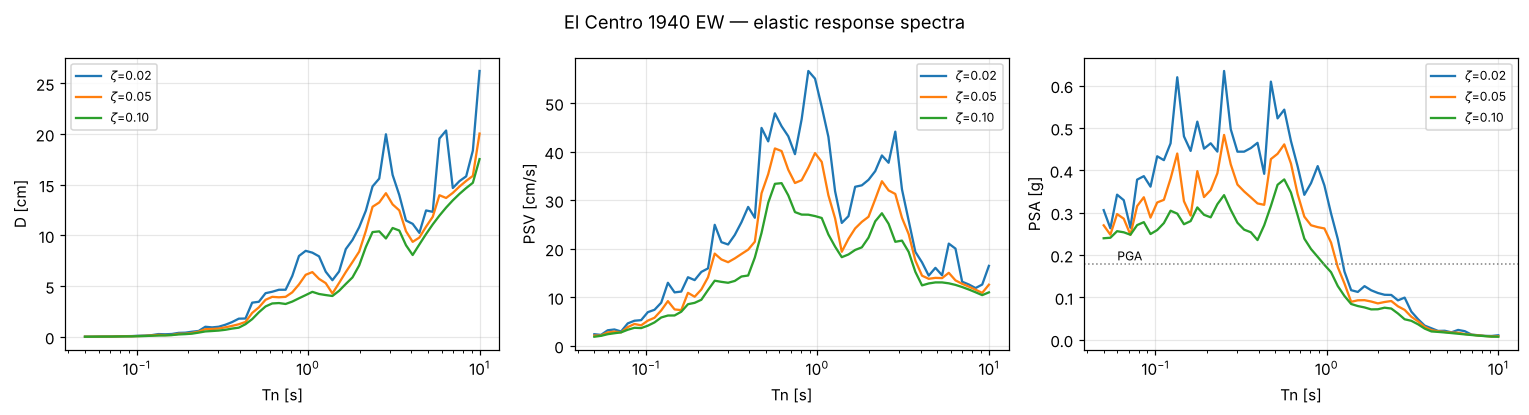

In [18]:
zetas = (0.02, 0.05, 0.10)
spec = {}
for z in zetas:
    D = np.array([sdof_piecewise_exact(ag_mps2, dt_g, T, z) for T in periods])
    w = 2 * np.pi / periods
    spec[z] = dict(D=D, V=w * D, A=w**2 * D / G_M_PER_S2)

A_short = (2 * np.pi / 0.01) ** 2 * sdof_piecewise_exact(ag_mps2, dt_g, 0.01, 0.05) / G_M_PER_S2
ok_pga = abs(A_short - PGA_g) / PGA_g < 0.05
ok_mono = all(np.all(spec[zetas[i]]["A"] >= spec[zetas[i + 1]]["A"] * 0.99) for i in range(len(zetas) - 1))
print(f"[검증] T = 0.01 s 의 PSA = {A_short:.3f} g  vs  PGA = {PGA_g:.3f} g  {verdict(ok_pga)}")
print(f"[검증] 감쇠비가 클수록 PSA가 작거나 같다 (1% 허용, 전 주기)  {verdict(ok_mono)}")
j1 = np.argmin(np.abs(periods - 1.0))
print(f"참고: 4장의 Tn = 1.0 s 결과 A = {np.max(np.abs(A_eq))/G_M_PER_S2:.3f} g 는 "
      f"이 스펙트럼의 T = {periods[j1]:.2f} s 점 ({spec[0.05]['A'][j1]:.3f} g)과 비슷해야 한다")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for z in zetas:
    axes[0].semilogx(periods, spec[z]["D"] * 100, label=rf"$\zeta$={z:.2f}")
    axes[1].semilogx(periods, spec[z]["V"] * 100, label=rf"$\zeta$={z:.2f}")
    axes[2].semilogx(periods, spec[z]["A"], label=rf"$\zeta$={z:.2f}")
axes[2].axhline(PGA_g, color="0.5", ls=":", lw=1); axes[2].text(0.06, PGA_g * 1.05, "PGA", fontsize=8)
for ax, lab in zip(axes, ("D [cm]", "PSV [cm/s]", "PSA [g]")):
    ax.set_xlabel("Tn [s]"); ax.set_ylabel(lab); ax.legend(fontsize=8)
fig.suptitle("El Centro 1940 EW — elastic response spectra"); plt.tight_layout(); plt.show()

### ✏️ 실습 4

1. `T_bldg`에 우리 학교 건물(또는 관심 있는 건물)의 1차 주기를 넣어 밑면전단계수 $V_b/W = A/g$를 읽어 보세요.
   간이식 $T \approx 0.073\,h_n^{3/4}$ (RC 모멘트골조, $h_n$ [m]; 확인 필요: 적용 기준 KDS 41 17 00 조항 대조)로 주기를 추정해도 됩니다.
2. 감쇠비 2% → 10%로 올리면 PSA가 몇 % 줄어드나요? 주기에 따라 감소율이 같은가요?
3. (도전) `data/` 폴더에 다른 기록(GroundMotionScaling 저장소의 `CHi_CHi_EW.txt`, `K.J_EW.txt`)을 넣고 `gm_path`를 바꿔 스펙트럼을 비교해 보세요.

In [19]:
T_bldg = 1.2                                                 # ← 바꿔 보세요 [s]

for z in zetas:
    A_b = (2 * np.pi / T_bldg) ** 2 * sdof_piecewise_exact(ag_mps2, dt_g, T_bldg, z) / G_M_PER_S2
    print(f"zeta = {z:.2f}:  PSA(T = {T_bldg} s) = {A_b:.3f} g  ->  Vb = {A_b:.3f} W")
A2 = (2 * np.pi / T_bldg) ** 2 * sdof_piecewise_exact(ag_mps2, dt_g, T_bldg, 0.02)
A10 = (2 * np.pi / T_bldg) ** 2 * sdof_piecewise_exact(ag_mps2, dt_g, T_bldg, 0.10)
print(f"2% -> 10% 감쇠: PSA {100*(1 - A10/A2):.1f} % 감소")

zeta = 0.02:  PSA(T = 1.2 s) = 0.218 g  ->  Vb = 0.218 W
zeta = 0.05:  PSA(T = 1.2 s) = 0.164 g  ->  Vb = 0.164 W
zeta = 0.10:  PSA(T = 1.2 s) = 0.116 g  ->  Vb = 0.116 W
2% -> 10% 감쇠: PSA 46.9 % 감소


---
## 정리

| 파트 | 오늘 확인한 것 |
| --- | --- |
| 1 | 감쇠비는 진폭의 지수 감소율. 피크 두 개로 역산할 수 있다 |
| 2 | 공진 응답은 $\approx u_{st}/(2\zeta)$. 단 정상상태까지 수 주기가 걸린다 |
| 3 | 평균가속도법은 발산하지 않지만 주기가 늘어난다. $\Delta t \le T_n/10\sim T_n/20$ |
| 4 | 지진은 $-m\ddot u_g$ 유효하중. 응답은 $T_n,\zeta$로만 정해진다 |
| 5 | 응답스펙트럼 = 최대응답의 모음. 짧은 주기는 dt 분할, $T\to0$에서 PGA |

**다음 주 연결:** MDOF로 확장 → 모드별로 SDOF 응답스펙트럼을 읽고 SRSS/CQC로 조합합니다.